In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("data_small.csv", encoding="latin1")

In [8]:
df.shape

(100000, 8)

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


1. Очистка данных
Необходимо:
1.1 убрать строки без CustomerID
1.2 проверить отрицательные Quantity (это возвраты)
1.3 привести InvoiceDate к datetime

In [10]:
print(df['CustomerID'].isna().sum())

34915


In [11]:
df = df[df['CustomerID'].notna()] #фильтруем по строкам где CustomerID не пустой

In [12]:
df.shape #стало меньше строк

(65085, 8)

In [ ]:
(df['Quantity'] < 0).sum() #создаем булеву маску и плюсуем true - итог у нас 1771 строк с возваратми 

np.int64(1771)

In [14]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [15]:
df = df[df['Quantity'] > 0] #фильтруем датафрейм чтобы убрать возвраты

1.3---------------------------------------------------------------------------------------

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) #исп метод конвертации to_datetime чтобы можно было агрегировать по дням/месяцам

In [17]:
type(df['InvoiceDate'][0])

pandas._libs.tslibs.timestamps.Timestamp

2. Создать базовые поля
Необходимо:

2.1 revenue = Quantity * UnitPrice
2.2 date (без времени)
2.3 month

2.1---------------------------------------------------------------------------------------

In [18]:
df['revenue'] = df['Quantity'] * df['UnitPrice'] #создает колонку с выручкой для каждой строки

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
df['revenue'].sum() #общая выручка в фунтах

np.float64(1519217.56)

2.2---------------------------------------------------------------------------------------

In [21]:
df['date'] = df['InvoiceDate'].dt.date #создаем колонку с типом данных datetime для дальнейшей работы с ним

In [22]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01


In [23]:
df['month'] = df['InvoiceDate'].dt.to_period('M') #добавляем еще колонку чтобы оставить лишь год и месяц

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12


3. Базовые метрики

Необходимо: 3.1 общая выручка 3.2 количество заказов (InvoiceNo) 3.3уникальные клиенты (CustomerID

In [25]:
total_revenue = df['revenue'].sum() #суммируем все строки столбца revenue 

In [ ]:
total_revenue #1519217.56

np.float64(1519217.56)

In [27]:
total_orders = df['InvoiceNo'].nunique()  #по причине что у нас в 1 заказе несколько товаров, считаем лишь число уник заказов, чтобы найти общее кол-во

In [ ]:
total_orders #3182

3182

In [29]:
unique_cust_count = df['CustomerID'].nunique()

In [30]:
unique_cust_count

1597

4. Анализ продаж
Необходимо:
4.1 выручка по дням
4.2 выручка по месяцам
4.3 количество заказов по времени

In [31]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12


In [32]:
daily_revenue = df.groupby('date')['revenue'].sum().sort_index()

In [33]:
daily_revenue

date
2010-12-01    46376.49
2010-12-02    47316.53
2010-12-03    23921.71
2010-12-05    31771.60
2010-12-06    31215.64
                ...   
2011-02-18    14463.06
2011-02-20     9624.69
2011-02-21    32801.73
2011-02-22    29160.48
2011-02-23    13753.45
Name: revenue, Length: 64, dtype: float64

In [34]:
monthly_revenue = df.groupby('month')['revenue'].sum().sort_index()

In [35]:
monthly_revenue

month
2010-12    572713.89
2011-01    569445.04
2011-02    377058.63
Freq: M, Name: revenue, dtype: float64

In [36]:
daily_orders_count = df.groupby('date')['InvoiceNo'].nunique()
monthly_orders_count = df.groupby('month')['InvoiceNo'].nunique()

In [37]:
daily_orders_count.sort_index().head()

date
2010-12-01    121
2010-12-02    137
2010-12-03     57
2010-12-05     87
2010-12-06     94
Name: InvoiceNo, dtype: int64

In [38]:
monthly_orders_count.sort_index().head()

month
2010-12    1400
2011-01     987
2011-02     795
Freq: M, Name: InvoiceNo, dtype: int64

Графики

In [39]:
import matplotlib.pyplot as plt

График ежендневной выручки

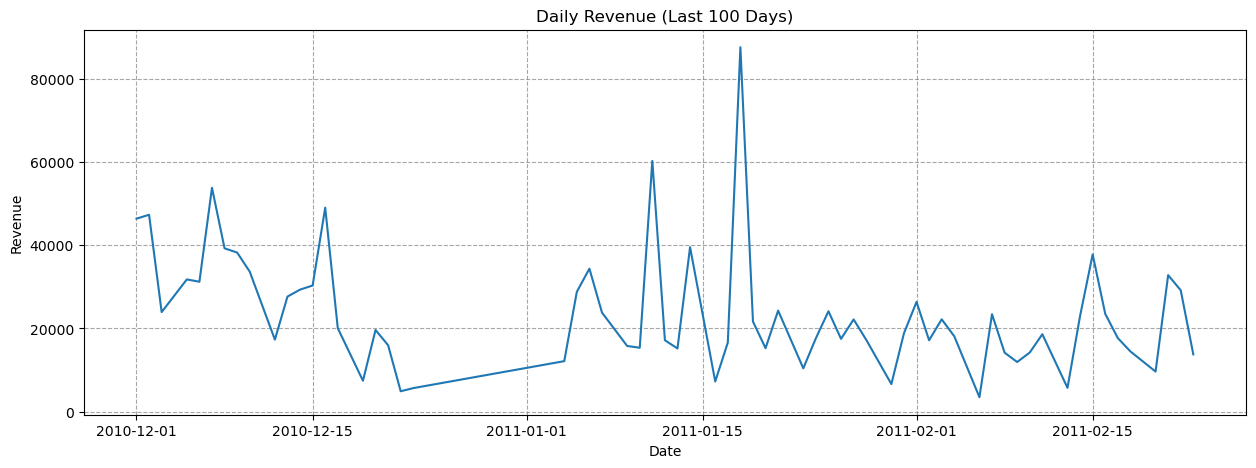

In [40]:
ax = daily_revenue.iloc[-100:].plot(figsize=(15,5))
ax.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.title('Daily Revenue (Last 100 Days)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

График ежемесячной выручки

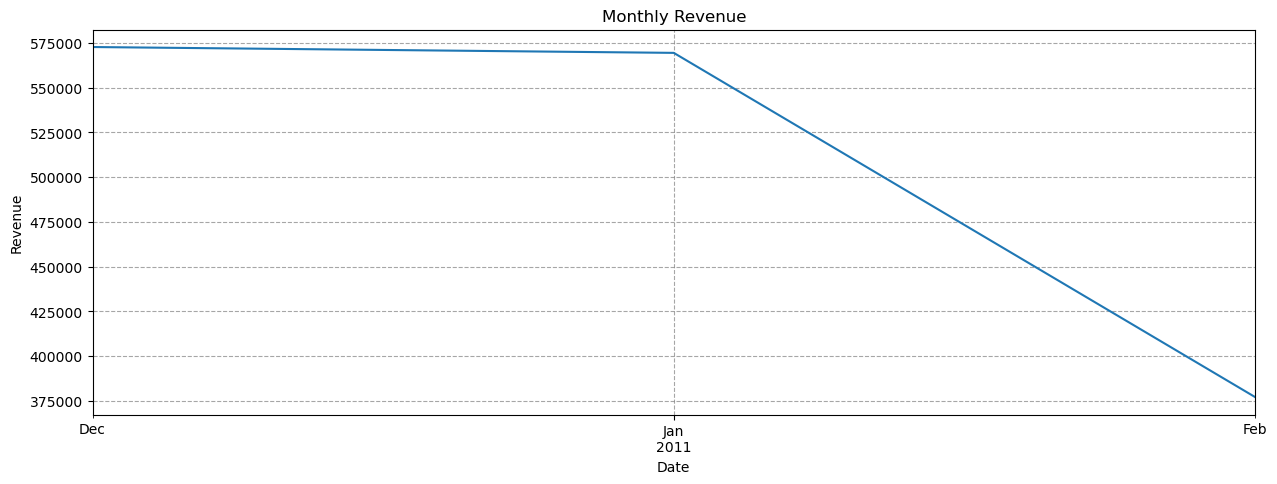

In [41]:
ax = monthly_revenue.plot(figsize=(15,5))
ax.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.title('Monthly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

График кол-ва ежедневных заказов

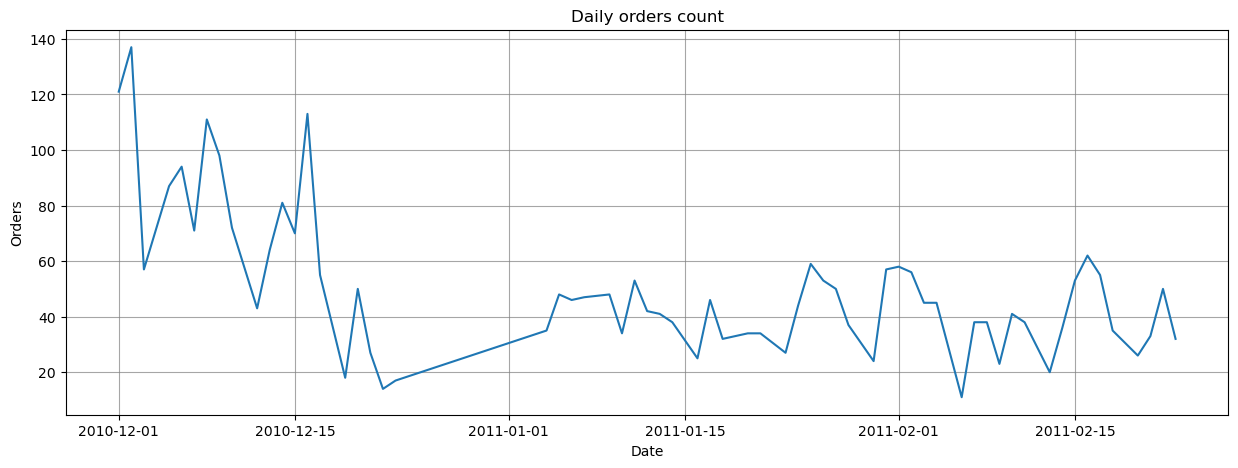

In [42]:
ax = daily_orders_count.plot(figsize=(15,5))
ax.grid(True, alpha=0.7, linestyle='-', color='gray')
plt.title('Daily orders count')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.show()

5. Анализ товаров

Необходимо:

5.1 топ товаров по выручке
5.2 топ товаров по количеству
5.3 товары с низкими продажами

In [43]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12


In [44]:
top5_by_revenue = df.groupby('Description')['revenue'].sum().sort_values(ascending=False).head(5)

In [45]:
top5_by_revenue

Description
MEDIUM CERAMIC TOP STORAGE JAR        77183.60
REGENCY CAKESTAND 3 TIER              37119.45
WHITE HANGING HEART T-LIGHT HOLDER    28856.80
CHILLI LIGHTS                         14703.81
VINTAGE UNION JACK MEMOBOARD          13929.23
Name: revenue, dtype: float64

In [46]:
top5_by_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5) #топ 5 по кол-ву проданных твоаров

In [47]:
top5_by_quantity

Description
MEDIUM CERAMIC TOP STORAGE JAR        74215
WHITE HANGING HEART T-LIGHT HOLDER    10674
WORLD WAR 2 GLIDERS ASSTD DESIGNS     10036
PACK OF 72 RETROSPOT CAKE CASES        8420
JUMBO BAG RED RETROSPOT                7236
Name: Quantity, dtype: int64

In [48]:
total_by_product = df.groupby('StockCode')['StockCode'].count().sort_values()

In [49]:
total_by_product.head()

StockCode
84691    1
45013    1
84466    1
44265    1
21003    1
Name: StockCode, dtype: int64

In [50]:
min_value = total_by_product.min()

In [51]:
lowest_sales_products_stock_id = total_by_product[total_by_product == min_value]

In [52]:
lowest_sales_products_stock_id.index

Index(['84691', '45013', '84466', '44265', '21003', '21002', '44236', '44228',
       '44092C', '21816',
       ...
       '90214D', '20700', '90214C', '35597B', '35265', '90212B', '90211B',
       '35597A', '85107', '85095'],
      dtype='object', name='StockCode', length=309)

6. Анализ клиентов

Необходимо:

6.1 сколько заказов у клиента
6.2 сколько он потратил
6.3 топ клиентов


In [53]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12


In [54]:
orders_cnt_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [55]:
orders_cnt_per_customer

CustomerID
12346.0    1
12347.0    2
12348.0    2
12350.0    1
12352.0    1
          ..
18257.0    2
18259.0    1
18260.0    2
18269.0    1
18283.0    2
Name: InvoiceNo, Length: 1597, dtype: int64

In [56]:
orders_cnt_per_customer.describe()

count    1597.000000
mean        1.992486
std         2.417292
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        41.000000
Name: InvoiceNo, dtype: float64

In [57]:
df['CustomerID'].nunique()

1597

6.2 -----------------------------------------------------

In [58]:
revenue_per_customer = df.groupby('CustomerID')['revenue'].sum()

In [59]:
revenue_per_customer.describe()

count     1597.000000
mean       951.294652
std       3161.126419
min          0.850000
25%        211.940000
50%        392.620000
75%        804.910000
max      77183.600000
Name: revenue, dtype: float64

In [60]:
customer_analysis = pd.concat(
    [orders_cnt_per_customer, revenue_per_customer],
    axis=1
)

In [61]:
customer_analysis

,InvoiceNo,revenue
CustomerID,,
12346.0,1,77183.60
12347.0,2,1187.18
12348.0,2,1120.24
12350.0,1,334.40
12352.0,1,296.50
...,...,...
18257.0,2,363.80
18259.0,1,376.30
18260.0,2,787.77


6.3 -----------------------------------------

In [62]:
top_customers_by_revenue = customer_analysis.sort_values('revenue', ascending=False).head(5)

In [63]:
top_customers_by_revenue

,InvoiceNo,revenue
CustomerID,,
12346.0,1,77183.60
14646.0,10,57866.02
18102.0,6,38370.09
14156.0,7,25752.25
15749.0,2,22998.40


Процесс сегментации

In [64]:
df2 = pd.DataFrame(orders_cnt_per_customer)

In [65]:
df2 = df2.rename(columns={'InvoiceNo' : 'Orders_count'})

In [66]:
df2.loc[df2['Orders_count'] == 1, 'status'] = 'new'
df2.loc[(df2['Orders_count'] == 2) | (df2['Orders_count'] == 3), 'status'] = 'returning'
df2.loc[df2['Orders_count'] >= 4, 'status'] = 'loyal'

In [67]:
df2.head()

,Orders_count,status
CustomerID,,
12346.0,1,new
12347.0,2,returning
12348.0,2,returning
12350.0,1,new
12352.0,1,new


7. Найти: 7.1средний чек: revenue / orders 7.2 выручка по странам 

In [68]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,date,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12


In [69]:
average_order_value = df['revenue'].sum() / df['InvoiceNo'].nunique() #average_order_value = total_revenue / total_orders

In [73]:
average_order_value.round(2)

np.float64(477.44)

In [71]:
revenue_by_country = df.groupby('Country')['revenue'].sum()

In [72]:
revenue_by_country

Country
Australia                 24333.43
Austria                     795.56
Belgium                    4851.33
Channel Islands            2823.82
Cyprus                     6472.56
Denmark                    1680.72
EIRE                      40844.59
Finland                    1781.82
France                    33870.52
Germany                   40044.33
Greece                     2661.24
Iceland                    1187.18
Israel                      779.10
Italy                      3470.01
Japan                     13485.88
Lebanon                    1693.88
Lithuania                  1661.06
Netherlands               58407.55
Norway                     4418.02
Poland                     1465.43
Portugal                   7469.33
Singapore                  2053.07
Spain                     14044.32
Sweden                     7830.12
Switzerland                6229.48
United Arab Emirates        889.24
United Kingdom          1233973.97
Name: revenue, dtype: float64